In [2]:
# Import libraries
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Connect to WRDS database (in-class standard code)
db = wrds.Connection(wrds_username="kehaowang")

Loading library list...
Done


In [5]:
# SQL Query (In-class format)
sql = """
    SELECT date, ret, vol
    FROM crsp.msf
    WHERE permno = 10107
    AND ret IS NOT NULL
    AND vol IS NOT NULL
    ORDER BY date
"""

# Get data from WRDS
df = db.raw_sql(sql)

In [6]:
df.head()

,date,ret,vol
0,1986-04-30,0.172727,19056.0
1,1986-05-30,0.077519,9810.0
2,1986-06-30,-0.115108,10238.0
3,1986-07-31,-0.073171,16057.0
4,1986-08-29,0.0,9239.0


In [7]:
# Data Cleaning
df['date'] = pd.to_datetime(df['date'])
df = df.dropna()

# Descriptive Statistics
df.describe()

,date,ret,vol
count,465,465.0,465.0
mean,2005-08-29 22:45:40.645161344,0.023498,6527732.823656
min,1986-04-30 00:00:00,-0.343529,9239.0
25%,1995-12-29 00:00:00,-0.035528,1021997.0
50%,2005-08-31 00:00:00,0.021519,5896759.0
75%,2015-04-30 00:00:00,0.068194,10281131.0
max,2024-12-31 00:00:00,0.515544,30441987.0
std,NaN,0.094047,5393593.901128


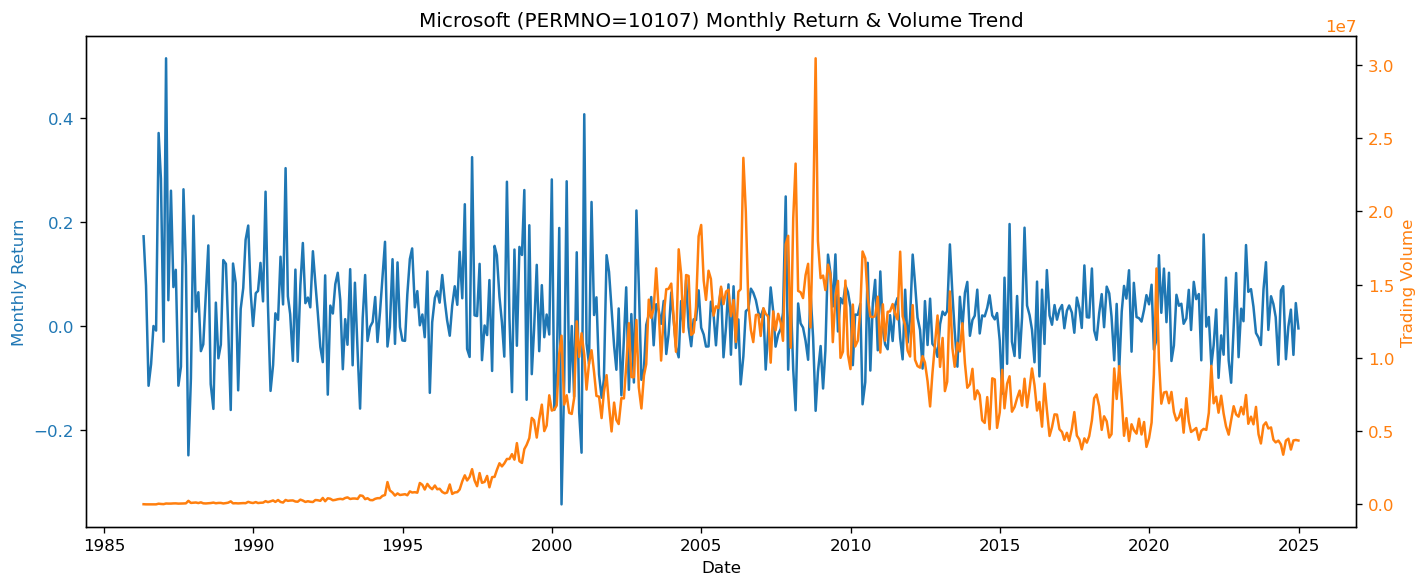

In [8]:
# Plot Return & Volume Trend
plt.rcParams['figure.dpi'] = 120

# Create dual-axis figure
fig, ax1 = plt.subplots(figsize=(12, 5))

# First axis: Monthly Return
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Monthly Return', color=color)
ax1.plot(df['date'], df['ret'], color=color, label='Monthly Return')
ax1.tick_params(axis='y', labelcolor=color)

# Second axis: Trading Volume
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Trading Volume', color=color)
ax2.plot(df['date'], df['vol'], color=color, label='Trading Volume')
ax2.tick_params(axis='y', labelcolor=color)

# Chart format
plt.title('Microsoft (PERMNO=10107) Monthly Return & Volume Trend')
fig.tight_layout()

# Save plot to local file
plt.savefig('trend_plot.png')
plt.show()

In [10]:
# Close WRDS database connection
try:
    db.close()
except Exception as e:
    print(f"Connection close note: {e}")

Connection close note: 'NoneType' object has no attribute 'dispose'


In [11]:
import os
# 直接打印出你文件在电脑里的完整硬盘地址
print("你的文件本地完整路径：")
print(os.getcwd())

你的文件本地完整路径：
C:\Users\Lenovo
